# 中断

中断在构建图很常见

主要提供了人机交互接口，让调用者不局限于开始执行的时候传入参数， 应该在图执行的过程中，也能够和用户交流， 执行到某一步，问用户，喜欢黑的还是白的，然后再继续往下执行，很重要

这个要实现，就依赖于langgraph的中断机制，有动态和静态两种，  
动态中断是核心，  
静态中断主要用于调试，实际开发用不到  


实际开发主要用核心的**动态中断**， 动态中断怎么实现的
- 在设计使用方法是简单清晰易用的，  langgraph直接让你在图的任意一个节点调用interrupt方法， 只要调用，整个图都会暂停，然后，就可以在代码的任意位置， 但是还是有使用规范，应该推荐怎么使用， 避免出现逻辑上的bug，要遵循规范，
- 但理论上，任何地方都能执行，执行后整个图保存，然后弹出，然后和人交互，传入新的指令，再恢复，再去运行，就叫动态中断，主要提供人机交互接口


**静态中断**在图编译的时候，就通过`interrupt_before`和`interrupt_after`，这两个参数 before和after要写在节点上，也有使用细节， 和超步有关， 说和节点的前后，不规范

# 动态中断（最核心）

## 描述
允许用户在图执行中，设置暂停点，所有内容保存下来， 然后等待用户输入指令，一般是字符串，输入完成之后， 我们的代码继续往下执行，就能实现人机交互的效果，

细节：
1. 当中断触发时，**`LangGraph`** 会通过持久化机制保存当前图状态，并无限期等待直到用户恢复执行。           =》 一定要配置checkpointer， 一般是数据库存储，中断的时候， 所有内容存在了检查点里面，检查点存在数据库里，所以永久保存，触发删除数据库内容。 （如果用户不想要之前的流程，  比如等1年之后不需要了， 用新的thread_id就行，就是持久化机制的又是）
2. 中断通过在任意图节点中调用 **`interrupt()`** 函数实现，该函数可以接收任何可 **`JSON`** 序列化的值，并将该值暴露给调用方。   =》 就是interrupt可以传参，传参的值需要是可以序列化的值，字符串可以， 整个内容
3. 中断触发后，调用方根据 **`interrupt()`** 暴露的信息生成反馈，重新调用图时通过 **`Command`** 将反馈传递给计算图，恢复图的运行。             =》 暴露的信息就是用户的选择，比如用户说我叫老王， 然后将老王重新调用图，  
4. 恢复运行后，调用方通过 **`Command`** 传递的反馈会作为 **`interrupt()`** 函数的返回值，参与后续计算。           =》 用户返回的内容  ，用command反馈到图里面， 图能够恢复运行， 简单理解 a = interruput(c),  c展示给用户看，   a就是用户给你的消息。  比如c你叫什么名字， a返回我叫老王， a再参与后续的计算


## 如何启用中断
前置条件
1. 持久化机制，  要配置checkpointer
2. 要设置thread_id ， 要保证中断后客回复执行， 要有完整的运行图状态，  如果配置in_memory， 内核一关闭，就不能恢复了，  如果配置数据库， 设置相同的thread_id，中断后还能恢复

使用：调用interupt


## 恢复中断
1. 用相同的配置再次调用图
2. 将输入替换成Command()实例 ，  实例里传入用户的反馈，  

然后langgraph就会从中断的节点，继续执行，这个节点会被再次运行， 从哪个节点中断跳出，就从哪里再次执行

（1 内部Command.resume将用户的反馈传给langgraph，中断的恢复执行，2  Command.resume也会作为原来的interupt()函数的返回值，继续逻辑）

## 常见的使用模式
核心的第一个HITL， 后面是第一个的展开


1. **基础 HITL 模式**：状态图触发一次中断，获取人类输入后继续执行。
2. **多个并行中断**：多个并行任务分别产生中断，并根据 **中断 `ID`** 接收各自的恢复数据。
3. **审批模式**：根据人类审批（批准、拒绝或其它处理方式），决定后续执行路径。
4. **审核与编辑模式**：将模型生成的内容交给人类检查，并允许人类直接修改后继续处理。
5. **工具执行审批模式**：在调用工具或执行具有副作用的操作之前，由人类确认是否允许执行。
6. **单节点串行中断模式**：在同一个节点内多次触发中断，上一个中断恢复后才能触发下一个。
7. **人类输入验证模式**：对人类输入进行校验；当输入不符合要求时，再次中断并要求重新输入。

人在环，把人的命令添加到整个图的自动化运行的流程当中，就是要人的反馈  
后面多个并行中断，还有后面审批一些东西都是细节， 本质都是Human in the loop
主动中断，的和核心，就是人参与做决策的作用，领导的作用就是审批决策，怎么作用

# HITL
讲完基础中断， 现在来讲基础的human in the loop样例代码

代码逻辑简单，让用户手动输入姓名

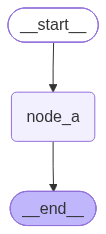

{'__interrupt__': [Interrupt(value='请输入您的姓名', id='f10f6b12a816ec5b4f538d3ad094ade2')]}


In [1]:
# 最基础的结构
# 1. 声明状态
from typing import TypedDict
from langgraph.types import interrupt
from dataclasses import dataclass
from typing import TypedDict, Annotated, Literal

from dotenv import  load_dotenv
from langchain_core import messages
from langchain_core.messages import SystemMessage,HumanMessage, AIMessage, ToolMessage
from langchain_deepseek import ChatDeepSeek
from langchain_experimental.graph_transformers.llm import system_prompt
from langgraph.graph import StateGraph,START,END
from langgraph.runtime import Runtime
from loguru import logger
from langgraph.checkpoint.postgres import  PostgresSaver
from langgraph.graph.message import MessagesState
from langgraph.checkpoint.memory import InMemorySaver


class OverAllState(TypedDict):
    username: str

# 2. 声明节点， 在节点里面，用中断的方式和用户询问对应的名称
def node_a(state: OverAllState) -> OverAllState:
    username = interrupt("请输入您的姓名")
    return {
        "username": username
    }

# 3. 构建图
builder = StateGraph(state_schema=OverAllState)
builder.add_node("node_a", node_a)
builder.add_edge(START, "node_a")
builder.add_edge("node_a", END)


# 4. 想要使用中断 =》 前提要求： 必须配置检查点， 不配置检查点不能用
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

display(graph)

config = {"configurable": {"thread_id": "123"}}
interrupt_res = graph.invoke({}, config=config)
print(interrupt_res)

In [ ]:
from langgraph.types import Command


prompt = interrupt_res['__interrupt__'][0].value

print(prompt)

username = input(prompt)

# 5. 恢复图的中断执行
resume_res = graph.invoke(Command(resume=username), config=config)  # config一定要填 ，

# 一般只能输入一次，  如何重复输入，应该要问ai修改

print(resume_res)

请输入您的姓名
{'username': '小花'}


补充：不一定调用interrupt就是HITL，  hITL必须人的参与，  程序自己恢复 就是普通的，就不是HITL